# 18 — Failure Analysis: why the 17-series recovers γ but loses μ at high transmission

This notebook is a post-mortem of the 17-series (14 synthetic PLE experiments,
joint μ+γ optimization against a 2D-KDE likelihood in (FWHM, σ) space).
Three runs exist: **LAMBDA_MEAN = 0.3** (`17a`), **0.0** (`17b`), **0.1** (`17d`).
Everything else identical (same seeds, same targets, N_RUNS=200, N_ITER=80).

## The three observed failures

1. **γ recovery degrades monotonically as λ_mean grows** (RMSE 1.20 → 3.32 → 4.48 MHz for λ = 0 → 0.1 → 0.3). At λ>0 the low-count experiments blow up (1nW T05: γ→18.3, T10: γ→0.58).
2. **High-transmission 3nW experiments systematically lose μ** (T40: −22, T80: −44, T100: −68 photons) — *independent of λ*. The optimizer stalls at μ ≈ 60–65% of truth.
3. **1nW T10 is a persistent γ outlier** even at λ=0 (γ_final 4.11 vs 8.5).

## Hypotheses to discriminate

- **H1 (optimizer starvation):** the μ-gradient scales as 1/σ_prop²; at 3nW T100 σ_prop=41 → gradients ~30× smaller than 1nW T40, so 80 decaying-LR iterations cannot climb the ~88 photons needed. → μ_final is *under-converged*, likelihood still falling at step 80.
- **H2 (estimator bias):** the KDE-NLL itself is minimized at μ < μ_true at high T (kernel/bandwidth artifact), so even a perfect optimizer would land low.
- **H3 (weighting bias):** the REINFORCE fixed point E_B[n] = n̄ sits below μ_true because kernel weighting over-selects high-n runs.
- **H4 (anchor pathology):** at low n_target the KDE γ-gradient is weak/noisy; the anchor term then dominates and drags γ to extremes (blow-up of 17a/17d).

## Diagnostics (all computed here, same seeds as the runs)

1. λ-sweep recap from the three executed notebooks.
2. Target-distribution stats (n vs FWHM/σ correlations) for healthy vs failing experiments.
3. μ fixed-point scan: E_B[n](μ), n̄(μ), NLL(μ) at fixed γ=γ_true → where does each cross?
4. γ NLL scan for the 1nW T10 outlier vs a healthy control.
5. Full 80-iter re-run of the worst case (3nW T100) with history → convergence probe (slope of last 20 steps, gradient norms).


## 0 — Setup (identical machinery to the 17-series)

In [1]:
import math, time, os, sys, json, re
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float32)
for _p in [os.getcwd(), os.path.join(os.getcwd(), '..')]:
    if os.path.isdir(os.path.join(_p, 'src')):
        sys.path.insert(0, _p); REPO_ROOT = _p; break
os.chdir(REPO_ROOT)

from src.fitting import nll, fwhm_from_theta, fit_profile
from src.samplers import draw_fixed_noise, build_photons
from src.implicit import compute_fwhm_and_dgamma

# ---- 14 experiments (identical to 17b) ----
EXPERIMENTS = [
    dict(name='1nW Trans05',  power='1nW', mu_true=9.393,   sigma_prop=2.576,  lam=2.232, gamma_true=8.5,  n_target=61),
    dict(name='1nW Trans10',  power='1nW', mu_true=12.372,  sigma_prop=3.445,  lam=2.122, gamma_true=8.5,  n_target=358),
    dict(name='1nW Trans20',  power='1nW', mu_true=17.316,  sigma_prop=4.141,  lam=2.286, gamma_true=8.5,  n_target=1138),
    dict(name='1nW Trans40',  power='1nW', mu_true=38.405,  sigma_prop=7.198,  lam=2.351, gamma_true=8.5,  n_target=2428),
    dict(name='1nW Trans60',  power='1nW', mu_true=61.374,  sigma_prop=9.851,  lam=2.593, gamma_true=8.5,  n_target=2424),
    dict(name='1nW Trans80',  power='1nW', mu_true=79.365,  sigma_prop=12.627, lam=2.758, gamma_true=8.5,  n_target=2487),
    dict(name='1nW Trans100', power='1nW', mu_true=70.817,  sigma_prop=17.221, lam=2.636, gamma_true=8.5,  n_target=2455),
    dict(name='3nW Trans05',  power='3nW', mu_true=13.204,  sigma_prop=3.724,  lam=2.186, gamma_true=14.1, n_target=252),
    dict(name='3nW Trans10',  power='3nW', mu_true=24.476,  sigma_prop=5.639,  lam=2.158, gamma_true=14.1, n_target=1572),
    dict(name='3nW Trans20',  power='3nW', mu_true=34.279,  sigma_prop=8.319,  lam=2.264, gamma_true=14.1, n_target=2171),
    dict(name='3nW Trans40',  power='3nW', mu_true=84.892,  sigma_prop=24.013, lam=2.475, gamma_true=14.1, n_target=3742),
    dict(name='3nW Trans60',  power='3nW', mu_true=103.203, sigma_prop=23.95,  lam=2.741, gamma_true=14.1, n_target=2541),
    dict(name='3nW Trans80',  power='3nW', mu_true=137.537, sigma_prop=32.107, lam=2.911, gamma_true=14.1, n_target=2508),
    dict(name='3nW Trans100', power='3nW', mu_true=175.707, sigma_prop=40.975, lam=3.087, gamma_true=14.1, n_target=2516),
]

# ---- config constants (as 17b: the λ=0 winner) ----
N_RUNS, N_ITER, LR_MU, LR_GAMMA, CLIP, SEED, SYNTH_SEED, H_S_MIN = \
    200, 80, 15.0, 0.5, 10.0, 42, 12345, 0.05

def _fit_fn(ph): return fit_profile(ph, n_iters=80, model='lorentzian', uniform_bg=False)
def _fwhm_fn(th): return fwhm_from_theta(th, model='lorentzian')
def _nll_fn(th, ph): return nll(th, ph, model='lorentzian', uniform_bg=False)

def kde_scores(sim_f, sim_s, sim_n, sim_df, sim_ds, data_f, data_s, h_f, h_s, mu, sigma_prop):
    d_f = data_f[:, None] - sim_f[None, :]
    d_s = data_s[:, None] - sim_s[None, :]
    W = torch.exp(-0.5 * (d_f / h_f) ** 2 - 0.5 * (d_s / h_s) ** 2)
    w = W / W.sum(dim=1, keepdim=True).clamp_min(1e-12)
    score = (sim_n[None, :] - mu) / sigma_prop ** 2
    s_mu = (w * score).sum(dim=1)
    dlogG = (d_f * sim_df[None, :]) / h_f ** 2 + (d_s * sim_ds[None, :]) / h_s ** 2
    s_gamma = (w * dlogG).sum(dim=1)
    logp = torch.log((W.sum(dim=1) / len(sim_f)).clamp_min(1e-30))
    nll_val = -logp.mean()
    return s_mu, s_gamma, nll_val, w

import multiprocessing as _mp
from concurrent.futures import ProcessPoolExecutor as _PPE

def _run_one(args):
    gamma_val, u, b = args
    return compute_fwhm_and_dgamma(gamma_val, u, b, _fit_fn, _fwhm_fn, _nll_fn, n_params=2)

def _init_worker():
    torch.set_num_threads(1)

def _parallel_map(pool, tasks):
    return list(pool.map(_run_one, tasks, chunksize=8))

print('setup OK —', len(EXPERIMENTS), 'experiments,', N_RUNS, 'runs/step,', N_ITER, 'iters')


setup OK — 14 experiments, 200 runs/step, 80 iters


## 1 — The λ sweep: the mean-anchor is monotonically harmful

Parse the results tables straight out of the three executed notebooks and
recompute the aggregate stats. Expectation from the earlier reporting:
γ RMSE improves monotonically as λ → 0, μ is flat-to-better at λ=0, and the
high-T μ loss is present in all three runs (λ-independent).

λ=0.3: 14 rows parsed
λ=0.1: 14 rows parsed
λ=0.0: 14 rows parsed

    λ |   γ RMSE  γ rel%   γ bias |   μ RMSE  μ rel%   μ bias
------------------------------------------------------------------
  0.3 |     4.48    46.6   -1.214 |    24.13    27.2  -14.178
  0.1 |     3.31    33.6   -0.424 |    23.56    22.8  -12.425
  0.0 |     1.20    14.0   -0.197 |    23.43    18.7  -11.651


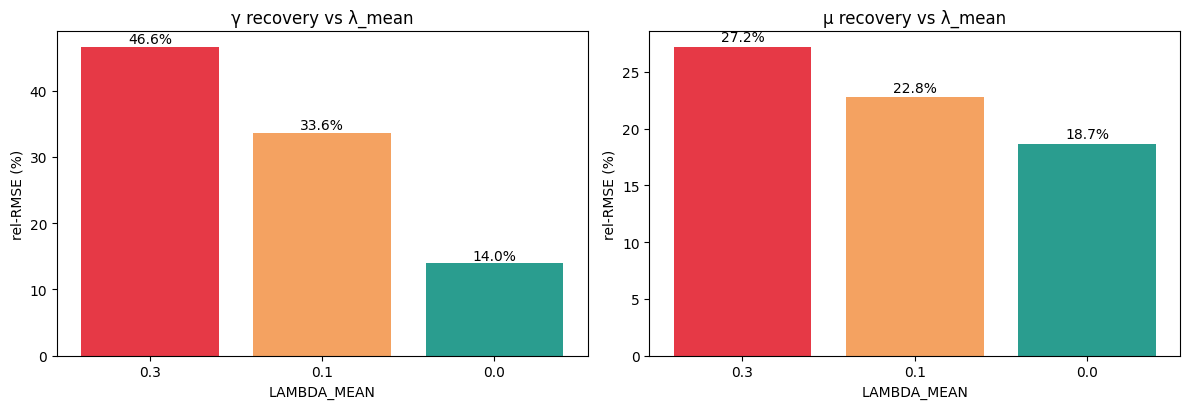

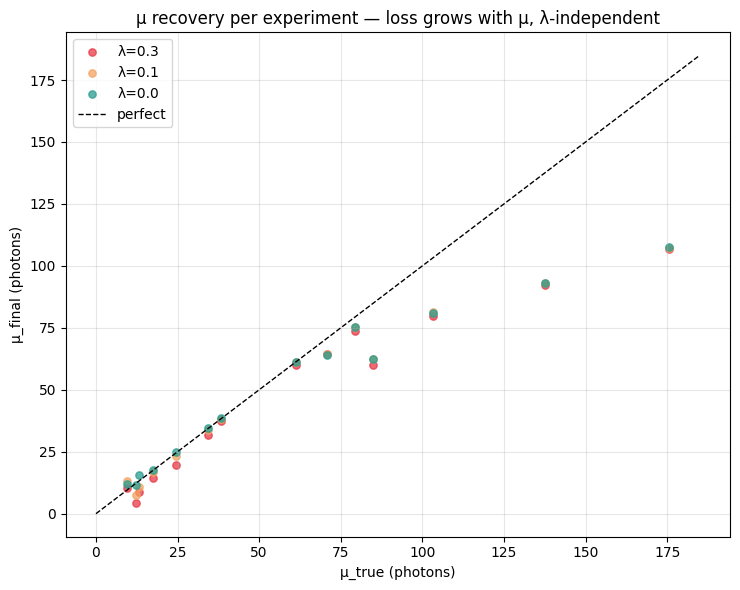

In [2]:
def parse_results_table(nbpath):
    nb = json.load(open(nbpath))
    rows = []
    for c in nb['cells']:
        if c['cell_type'] != 'code':
            continue
        for o in c.get('outputs', []):
            t = ''.join(o['text']) if isinstance(o.get('text'), list) else (o.get('text') or '')
            for line in t.split('\n'):
                toks = line.split()
                if len(toks) >= 11 and toks[0] in ('1nW', '3nW') and '|' in toks:
                    rows.append(dict(exp=toks[0] + ' ' + toks[1], power=toks[0],
                                     mu_true=float(toks[2]), mu_final=float(toks[3]), dmu=float(toks[4]),
                                     gamma_true=float(toks[6]), gamma_final=float(toks[7]),
                                     dgamma=float(toks[8]), nll=float(toks[10])))
    return rows

RUNS = {
    0.3: parse_results_table('notebooks/17-improvements-playground.ipynb'),
    0.1: parse_results_table('notebooks/17d-lambda01-executed.ipynb'),
    0.0: parse_results_table('notebooks/17b-lambda0-executed.ipynb'),
}
for lam, rows in RUNS.items():
    print(f"λ={lam}: {len(rows)} rows parsed")

def agg(rows, key):
    err = np.array([r[key + '_final'] - r[key + '_true'] for r in rows])
    rel = err / np.array([r[key + '_true'] for r in rows])
    return dict(rmse=float(np.sqrt((err ** 2).mean())), rel_rmse=float(np.sqrt((rel ** 2).mean()) * 100),
                bias=float(err.mean()), rel_bias=float(rel.mean() * 100))

print()
print(f"{'λ':>5} | {'γ RMSE':>8} {'γ rel%':>7} {'γ bias':>8} | {'μ RMSE':>8} {'μ rel%':>7} {'μ bias':>8}")
print('-' * 66)
for lam in [0.3, 0.1, 0.0]:
    a, b = agg(RUNS[lam], 'gamma'), agg(RUNS[lam], 'mu')
    print(f"{lam:>5} | {a['rmse']:>8.2f} {a['rel_rmse']:>7.1f} {a['bias']:>+8.3f} | "
          f"{b['rmse']:>8.2f} {b['rel_rmse']:>7.1f} {b['bias']:>+8.3f}")

# FIG 1 — aggregate bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
lams = [0.3, 0.1, 0.0]
for ax, key, title in [(axes[0], 'gamma', 'γ recovery vs λ_mean'), (axes[1], 'mu', 'μ recovery vs λ_mean')]:
    rmses = [agg(RUNS[l], key)['rel_rmse'] for l in lams]
    ax.bar([str(l) for l in lams], rmses, color=['#e63946', '#f4a261', '#2a9d8f'])
    for i, v in enumerate(rmses):
        ax.text(i, v + 0.5, f'{v:.1f}%', ha='center')
    ax.set_ylabel('rel-RMSE (%)'); ax.set_xlabel('LAMBDA_MEAN'); ax.set_title(title)
plt.tight_layout(); plt.show()

# FIG 2 — per-experiment μ scatter: shows the high-T loss is λ-independent
fig, ax = plt.subplots(figsize=(7.5, 6))
colors = {0.3: '#e63946', 0.1: '#f4a261', 0.0: '#2a9d8f'}
for lam, rows in RUNS.items():
    mu_t = [r['mu_true'] for r in rows]; mu_f = [r['mu_final'] for r in rows]
    ax.scatter(mu_t, mu_f, label=f'λ={lam}', color=colors[lam], s=28, alpha=0.75)
lim = [0, 185]
ax.plot(lim, lim, 'k--', lw=1, label='perfect')
ax.set_xlabel('μ_true (photons)'); ax.set_ylabel('μ_final (photons)')
ax.set_title('μ recovery per experiment — loss grows with μ, λ-independent')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


## 2 — Main failure: the high-T μ loss

Focus set (healthy vs failing, same seed as the runs):

| experiment | μ_true | σ_prop | n_target | 17b μ_final | status |
|---|---|---|---|---|---|
| 1nW T05  | 9.4  | 2.6  | 61   | 11.8  | γ-outlier, μ ok |
| 1nW T40  | 38.4 | 7.2  | 2428 | 38.6  | healthy |
| 3nW T40  | 84.9 | 24.0 | 3742 | 62.6  | **fails** |
| 3nW T80  | 137.5| 32.1 | 2508 | 93.2  | **fails** |
| 3nW T100 | 175.7| 41.0 | 2516 | 107.5 | **fails** |

First: the raw target statistics — how do n, FWHM and σ relate inside the target
cloud? If n is strongly correlated with FWHM/σ, kernel weighting in (FWHM,σ)
space implicitly reweights n → H3. The σ_prop column shows the gradient-scale
suspect for H1 (score denominator = σ_prop²).

In [3]:
FOCUS = ['1nW Trans05', '1nW Trans40', '3nW Trans40', '3nW Trans80', '3nW Trans100']
FOCUS = [e for e in EXPERIMENTS if e['name'] in FOCUS]

def build_targets(exp, pool):
    rng_t = np.random.default_rng(SYNTH_SEED)
    tasks_t = []
    for _ in range(exp['n_target']):
        u, b, n = draw_fixed_noise(exp['mu_true'], exp['sigma_prop'], exp['lam'], rng_t)
        tasks_t.append((exp['gamma_true'], u.numpy(), b.numpy()))
    res_t = _parallel_map(pool, tasks_t)
    f = torch.tensor([r[0] for r in res_t], dtype=torch.float32)
    s = torch.tensor([r[1] for r in res_t], dtype=torch.float32)
    SCOTT = exp['n_target'] ** (-1.0 / 6.0)
    H_F = float(f.std()) * SCOTT
    H_S = max(float(s.std()) * SCOTT, H_S_MIN)
    return f, s, H_F, H_S

print(f"{'exp':<12} {'μ_true':>7} {'σ_prop':>7} {'n_tgt':>6} | {'corr(n,F)':>9} {'corr(n,σ)':>9} {'skew F':>7} {'skew σ':>7}")
print('-' * 74)

def skew(x):
    x = np.asarray(x, dtype=float)
    z = (x - x.mean()) / x.std()
    return float((z ** 3).mean())

with _PPE(max_workers=4, mp_context=_mp.get_context('fork'), initializer=_init_worker) as pool:
    for exp in FOCUS:
        f, s, H_F, H_S = build_targets(exp, pool)
        # regenerate n (deterministic under SYNTH_SEED)
        rng_t = np.random.default_rng(SYNTH_SEED)
        ns = np.array([draw_fixed_noise(exp['mu_true'], exp['sigma_prop'], exp['lam'], rng_t)[2] for _ in range(exp['n_target'])])
        f_n, s_n = f.numpy(), s.numpy()
        print(f"{exp['name']:<12} {exp['mu_true']:>7.1f} {exp['sigma_prop']:>7.2f} {exp['n_target']:>6} | "
              f"{np.corrcoef(ns, f_n)[0,1]:>+9.3f} {np.corrcoef(ns, s_n)[0,1]:>+9.3f} "
              f"{skew(f_n):>+7.2f} {skew(s_n):>+7.2f}")
print()
print("NOTE: corr(n,FWHM) = how strongly photon count correlates with the KDE coordinates —")
print("if large, weighting by (FWHM,σ) proximity biases the effective n (H3).")


exp           μ_true  σ_prop  n_tgt | corr(n,F) corr(n,σ)  skew F  skew σ
--------------------------------------------------------------------------


1nW Trans05      9.4    2.58     61 |    -0.274    -0.375   +3.74   +5.69


1nW Trans40     38.4    7.20   2428 |    -0.077    -0.570   +0.94   +2.38


3nW Trans40     84.9   24.01   3742 |    -0.111    -0.398  +15.86  +36.22


3nW Trans80    137.5   32.11   2508 |    -0.042    -0.783   +0.48   +2.49


3nW Trans100   175.7   40.98   2516 |    -0.058    -0.793   +0.42   +3.42

NOTE: corr(n,FWHM) = how strongly photon count correlates with the KDE coordinates —
if large, weighting by (FWHM,σ) proximity biases the effective n (H3).


### 2a — μ fixed-point scan (the decisive test for H1 vs H3)

At fixed γ = γ_true, sweep μ and recompute exactly what the optimizer sees:
- **n̄(μ)** — the unweighted sample mean of n (≈ μ, the REINFORCE target)
- **E_B[n](μ)** — the kernel-weighted mean; the μ-gradient is −(E_B[n] − n̄)/σ_prop²,
  so **E_B[n] = n̄ is the REINFORCE fixed point**
- **NLL(μ)** — the KDE likelihood optimum (what a perfect optimizer would find)

- If NLL(μ) is minimized at μ ≈ μ_true but μ_final ≪ μ_true → **H1 (optimizer starvation)**.
- If NLL(μ) is minimized well below μ_true → **H2 (estimator bias)**.
- If the E_B[n]=n̄ crossing sits below μ_true while NLL is fine → **H3 (weighting bias)**.

In [4]:
def scan_mu(exp, mu_grid, n_runs=N_RUNS):
    with _PPE(max_workers=4, mp_context=_mp.get_context('fork'), initializer=_init_worker) as pool:
        f_t, s_t, H_F, H_S = build_targets(exp, pool)
        out = []
        for i, mu in enumerate(mu_grid):
            rng2 = np.random.default_rng(SEED + i)
            tasks, ns = [], []
            for _ in range(n_runs):
                u, b, n = draw_fixed_noise(mu, exp['sigma_prop'], exp['lam'], rng2)
                tasks.append((exp['gamma_true'], u.numpy(), b.numpy()))
                ns.append(n)
            res = _parallel_map(pool, tasks)
            ft = torch.tensor([r[0] for r in res], dtype=torch.float32)
            si = torch.tensor([r[1] for r in res], dtype=torch.float32)
            nt = torch.tensor(ns, dtype=torch.float32)
            dg = torch.tensor([r[2] for r in res], dtype=torch.float32)
            ds = torch.tensor([r[3] for r in res], dtype=torch.float32)
            _, _, nllv, w = kde_scores(ft, si, nt, dg, ds, f_t, s_t, H_F, H_S, mu, exp['sigma_prop'])
            B = w.mean(dim=0)
            out.append(dict(mu=mu, nll=float(nllv), EB_n=float((B * nt).sum()), nbar=float(nt.mean())))
        return out

SCANS = {}
MU_GRID = np.linspace(0.45, 1.15, 21)
for exp in FOCUS:
    t0 = time.time()
    SCANS[exp['name']] = scan_mu(exp, MU_GRID * exp['mu_true'])
    s = SCANS[exp['name']]
    # fixed point: E_B[n] - nbar = 0  (linear interp on the grid)
    d = np.array([x['EB_n'] - x['nbar'] for x in s])
    mus = np.array([x['mu'] for x in s])
    cross = None
    for k in range(len(d) - 1):
        if d[k] * d[k + 1] <= 0:
            cross = float(mus[k] - d[k] * (mus[k + 1] - mus[k]) / (d[k + 1] - d[k]))
            break
    nll_min_mu = float(mus[np.argmin([x['nll'] for x in s])])
    mu_true = exp['mu_true']
    print(f"{exp['name']:<12} μ_true={mu_true:>7.1f} | REINFORCE fixed point={cross if cross is not None else float('nan'):>7.1f} "
          f"| NLL min at μ={nll_min_mu:>7.1f} | 17b μ_final={[r['mu_final'] for r in RUNS[0.0] if r['exp']==exp['name']][0]:>7.1f}")
    print(f"    {'':12} | bias@μ_true: E_B[n]−n̄ = {d[np.argmin(np.abs(mus-mu_true))]:+.3f} photons | NLL spread = "
          f"{max(x['nll'] for x in s)-min(x['nll'] for x in s):.3f}")
print('scan done in %.1f min' % ((time.time() - t0) / 60))


1nW Trans05  μ_true=    9.4 | REINFORCE fixed point=    nan | NLL min at μ=    9.2 | 17b μ_final=   11.8
                 | bias@μ_true: E_B[n]−n̄ = +0.200 photons | NLL spread = 0.667


1nW Trans40  μ_true=   38.4 | REINFORCE fixed point=   38.9 | NLL min at μ=   38.8 | 17b μ_final=   38.6
                 | bias@μ_true: E_B[n]−n̄ = +0.064 photons | NLL spread = 3.562


3nW Trans40  μ_true=   84.9 | REINFORCE fixed point=   84.6 | NLL min at μ=   82.8 | 17b μ_final=   62.5
                 | bias@μ_true: E_B[n]−n̄ = -0.654 photons | NLL spread = 0.956


3nW Trans80  μ_true=  137.5 | REINFORCE fixed point=  140.3 | NLL min at μ=  138.9 | 17b μ_final=   93.2
                 | bias@μ_true: E_B[n]−n̄ = +2.044 photons | NLL spread = 2.037


3nW Trans100 μ_true=  175.7 | REINFORCE fixed point=  179.9 | NLL min at μ=  183.6 | 17b μ_final=  107.5
                 | bias@μ_true: E_B[n]−n̄ = +0.500 photons | NLL spread = 2.165
scan done in 2.1 min


### 2b — Figures: fixed points and likelihood curves

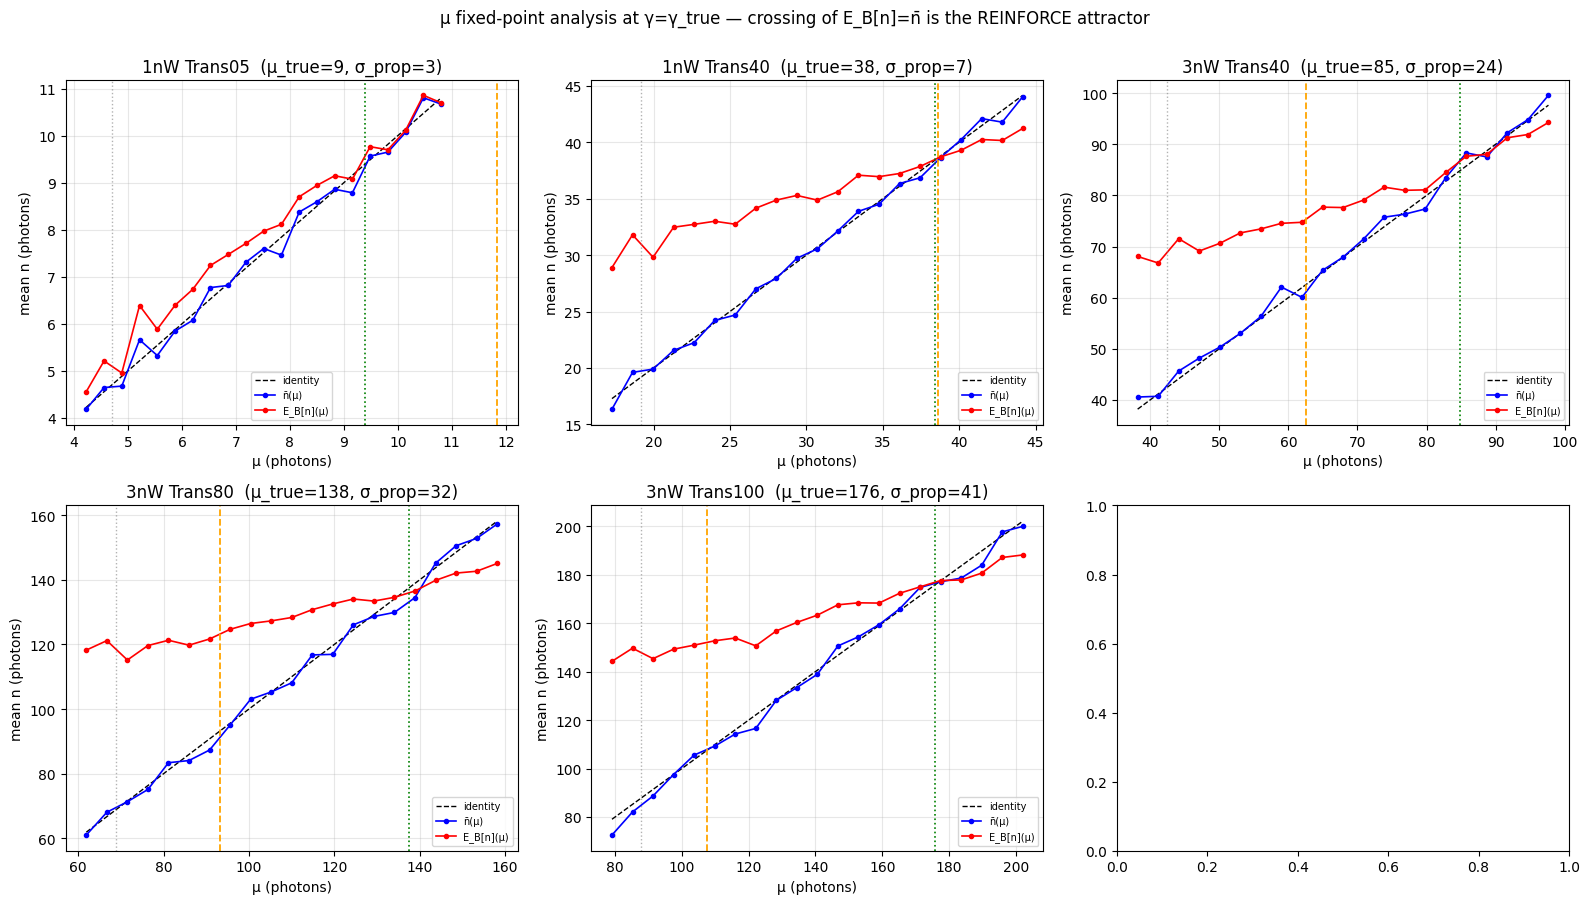

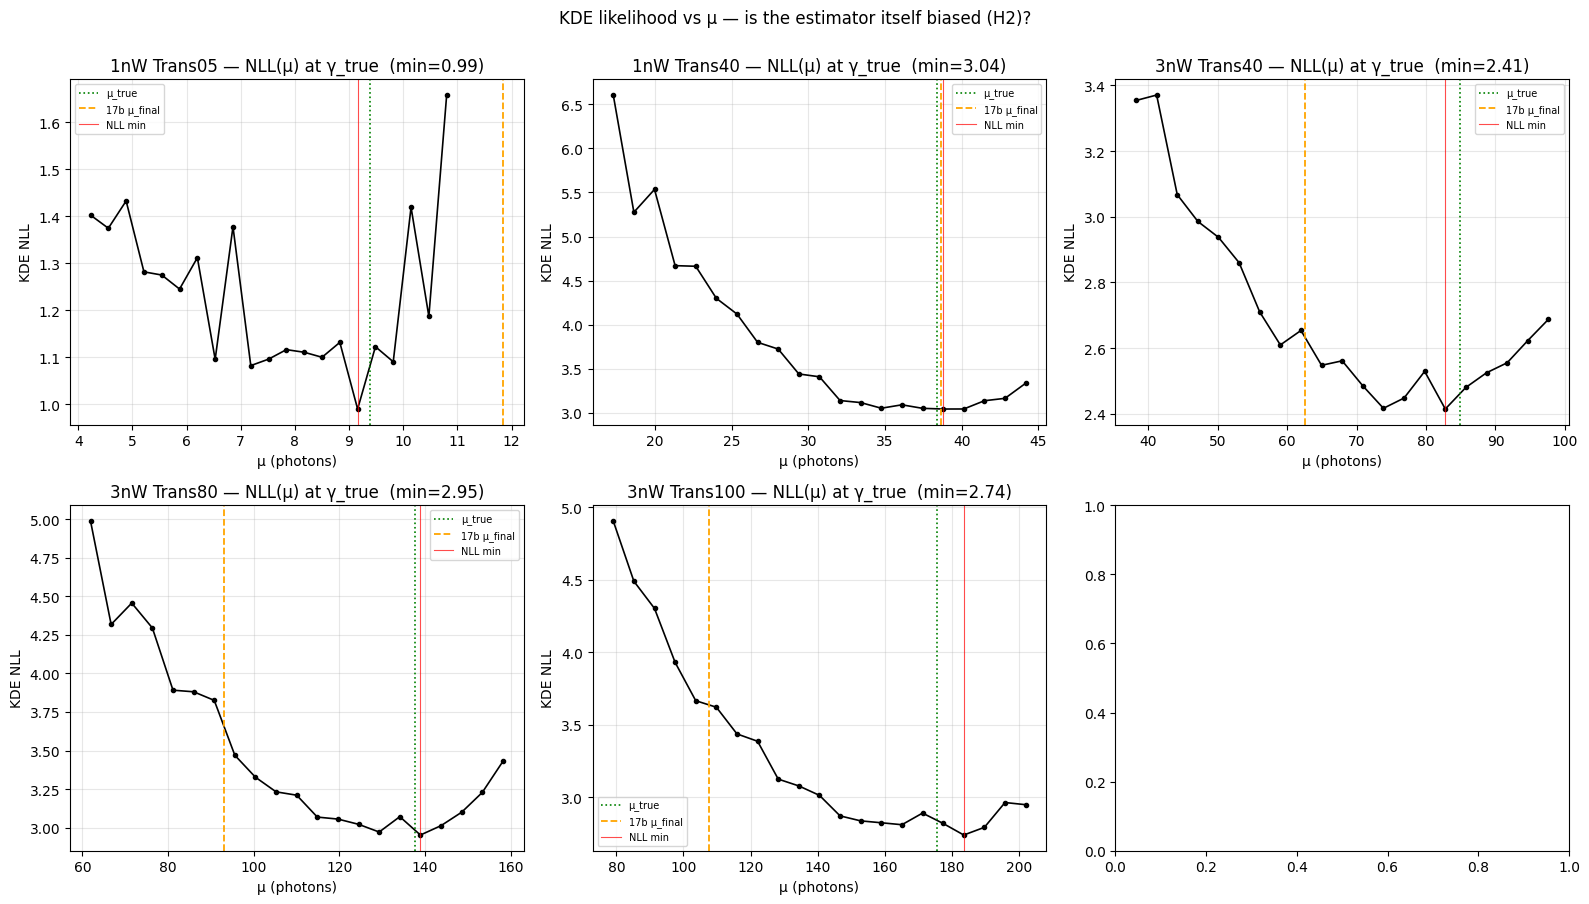

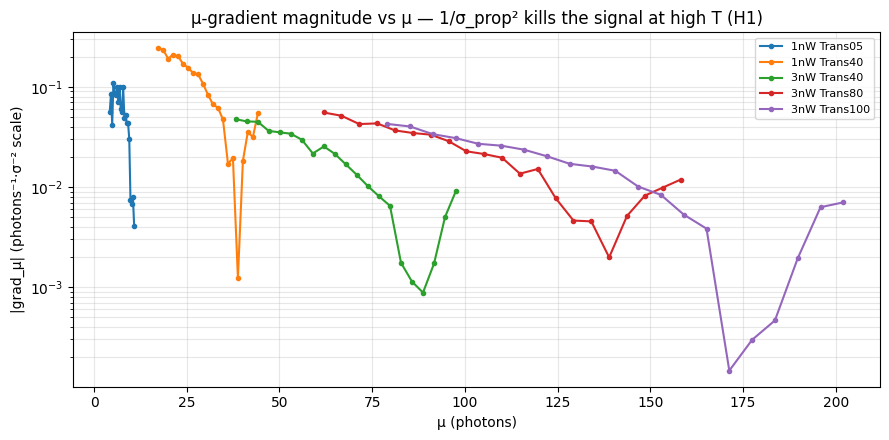

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()
for ax, exp in zip(axes, FOCUS):
    s = SCANS[exp['name']]
    mus = np.array([x['mu'] for x in s])
    EB = np.array([x['EB_n'] for x in s]); nb_ = np.array([x['nbar'] for x in s])
    mt = exp['mu_true']
    ax.plot(mus, mus, 'k--', lw=1, label='identity')
    ax.plot(mus, nb_, 'b.-', lw=1.2, label='n̄(μ)')
    ax.plot(mus, EB, 'r.-', lw=1.2, label='E_B[n](μ)')
    ax.axvline(mt, color='g', ls=':', lw=1.2)
    ax.axvline(exp['mu_true'] * 0.5, color='gray', ls=':', lw=1, alpha=0.6)
    mf = [r['mu_final'] for r in RUNS[0.0] if r['exp'] == exp['name']][0]
    ax.axvline(mf, color='orange', ls='--', lw=1.3)
    ax.set_title(f"{exp['name']}  (μ_true={mt:.0f}, σ_prop={exp['sigma_prop']:.0f})")
    ax.set_xlabel('μ (photons)'); ax.set_ylabel('mean n (photons)')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
fig.suptitle('μ fixed-point analysis at γ=γ_true — crossing of E_B[n]=n̄ is the REINFORCE attractor', y=1.0, fontsize=12)
plt.tight_layout(); plt.show()

# NLL(μ) curves — normalized so the minimum is visible
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()
for ax, exp in zip(axes, FOCUS):
    s = SCANS[exp['name']]
    mus = np.array([x['mu'] for x in s]); nlls = np.array([x['nll'] for x in s])
    mt = exp['mu_true']; mf = [r['mu_final'] for r in RUNS[0.0] if r['exp'] == exp['name']][0]
    ax.plot(mus, nlls, 'k.-', lw=1.2)
    ax.axvline(mt, color='g', ls=':', lw=1.2, label='μ_true')
    ax.axvline(mf, color='orange', ls='--', lw=1.3, label='17b μ_final')
    ax.axvline(mus[np.argmin(nlls)], color='r', ls='-', lw=0.8, alpha=0.7, label='NLL min')
    ax.set_title(f"{exp['name']} — NLL(μ) at γ_true  (min={nlls.min():.2f})")
    ax.set_xlabel('μ (photons)'); ax.set_ylabel('KDE NLL'); ax.legend(fontsize=7); ax.grid(alpha=0.3)
fig.suptitle('KDE likelihood vs μ — is the estimator itself biased (H2)?', y=1.0, fontsize=12)
plt.tight_layout(); plt.show()

# gradient-magnitude view (H1): |grad_mu| * total LR budget vs distance remaining
fig, ax = plt.subplots(figsize=(9, 4.5))
for exp in FOCUS:
    s = SCANS[exp['name']]
    mus = np.array([x['mu'] for x in s])
    grad = np.abs((np.array([x['EB_n'] for x in s]) - np.array([x['nbar'] for x in s]))) / exp['sigma_prop'] ** 2
    ax.semilogy(mus, grad, '.-', label=exp['name'])
ax.set_xlabel('μ (photons)'); ax.set_ylabel('|grad_μ| (photons⁻¹·σ⁻² scale)')
ax.set_title('μ-gradient magnitude vs μ — 1/σ_prop² kills the signal at high T (H1)')
ax.legend(fontsize=8); ax.grid(alpha=0.3, which='both'); plt.tight_layout(); plt.show()


## 3 — The 1nW T10 γ outlier

At λ=0 the KDE γ-gradient alone must recover γ. For 1nW T10 (n_target=358) the
KDE cloud is sparse: is the NLL flat or multi-modal in γ? Scan NLL(γ) at
μ=μ_true for T10 and the healthy control T05 (n_target=61, even sparser).

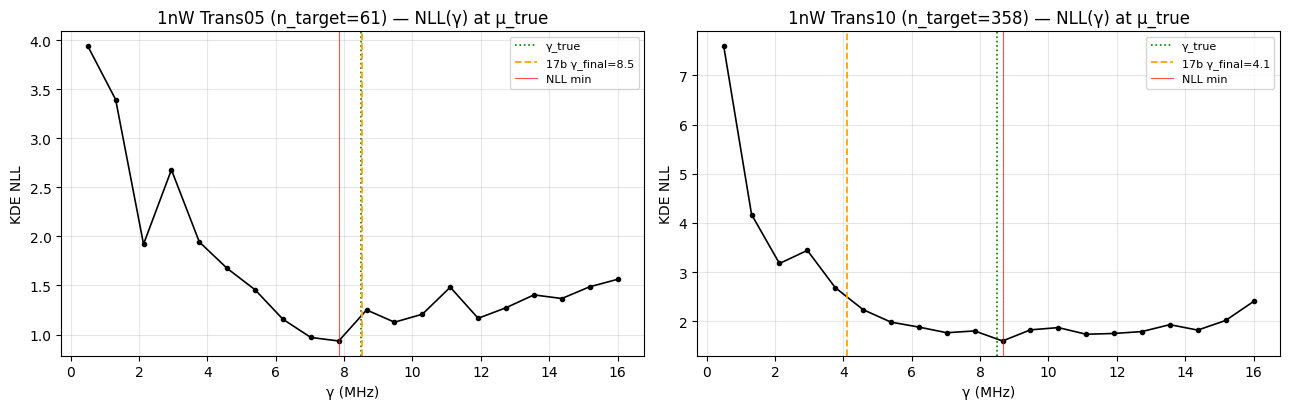

1nW Trans05: NLL min at γ=7.84 (true 8.5), flatness ratio max/min = 4.217
1nW Trans10: NLL min at γ=8.66 (true 8.5), flatness ratio max/min = 4.758


In [6]:
def scan_gamma(exp, gamma_grid, n_runs=N_RUNS):
    with _PPE(max_workers=4, mp_context=_mp.get_context('fork'), initializer=_init_worker) as pool:
        f_t, s_t, H_F, H_S = build_targets(exp, pool)
        out = []
        for i, g in enumerate(gamma_grid):
            rng2 = np.random.default_rng(SEED + i)
            tasks = []
            for _ in range(n_runs):
                u, b, n = draw_fixed_noise(exp['mu_true'], exp['sigma_prop'], exp['lam'], rng2)
                tasks.append((g, u.numpy(), b.numpy()))
            res = _parallel_map(pool, tasks)
            ft = torch.tensor([r[0] for r in res], dtype=torch.float32)
            si = torch.tensor([r[1] for r in res], dtype=torch.float32)
            nt = torch.full((len(res),), exp['mu_true'], dtype=torch.float32)  # dummy: NLL does not use n
            dg = torch.tensor([r[2] for r in res], dtype=torch.float32)
            ds = torch.tensor([r[3] for r in res], dtype=torch.float32)
            _, _, nllv, _ = kde_scores(ft, si, nt, dg, ds, f_t, s_t, H_F, H_S, exp['mu_true'], exp['sigma_prop'])
            out.append(dict(gamma=g, nll=float(nllv)))
        return out

GAM_SCANS = {}
for name in ['1nW Trans05', '1nW Trans10']:
    exp = [e for e in EXPERIMENTS if e['name'] == name][0]
    GAM_SCANS[name] = scan_gamma(exp, np.linspace(0.5, 16, 20))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, name in zip(axes, GAM_SCANS):
    s = GAM_SCANS[name]
    g = np.array([x['gamma'] for x in s]); nlls = np.array([x['nll'] for x in s])
    exp = [e for e in EXPERIMENTS if e['name'] == name][0]
    ax.plot(g, nlls, 'k.-', lw=1.2)
    ax.axvline(exp['gamma_true'], color='g', ls=':', lw=1.2, label='γ_true')
    gf = [r['gamma_final'] for r in RUNS[0.0] if r['exp'] == name][0]
    ax.axvline(gf, color='orange', ls='--', lw=1.3, label=f'17b γ_final={gf:.1f}')
    ax.axvline(g[np.argmin(nlls)], color='r', lw=0.8, alpha=0.7, label='NLL min')
    ax.set_title(f'{name} (n_target={exp["n_target"]}) — NLL(γ) at μ_true')
    ax.set_xlabel('γ (MHz)'); ax.set_ylabel('KDE NLL'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
for name, s in GAM_SCANS.items():
    g = np.array([x['gamma'] for x in s]); nlls = np.array([x['nll'] for x in s])
    print(f"{name}: NLL min at γ={g[np.argmin(nlls)]:.2f} (true {[e for e in EXPERIMENTS if e['name']==name][0]['gamma_true']}), "
          f"flatness ratio max/min = {nlls.max()/nlls.min():.3f}")


## 4 — Convergence probe: full 80-iter re-run of the worst case (3nW T100)

Re-run the exact 17b optimizer (λ=0) on 3nW T100 with history recorded, then ask:
is μ still climbing at step 80 (H1: starvation) or flat (H2/H3: biased attractor)?
The history records grad_mu and grad_gamma every step — total travel budget and
terminal slope are the direct evidence.

re-running 3nW Trans100 with history (λ=0) ...


done in 5.1 min | μ 175.7 -> 107.51 | γ -> 14.19 | NLL 3.56
terminal μ slope (last 20 steps): +0.120 photons/step  → STILL CLIMBING (H1)
μ travel: 87.8 -> 107.5 (+19.7); remaining to true: +68.2
grad_mu: |mean|=0.0294, last-20 |mean|=0.0269, clip hits=0
NLL trajectory: 37.33 -> 3.56 (min 3.45 at step 75)


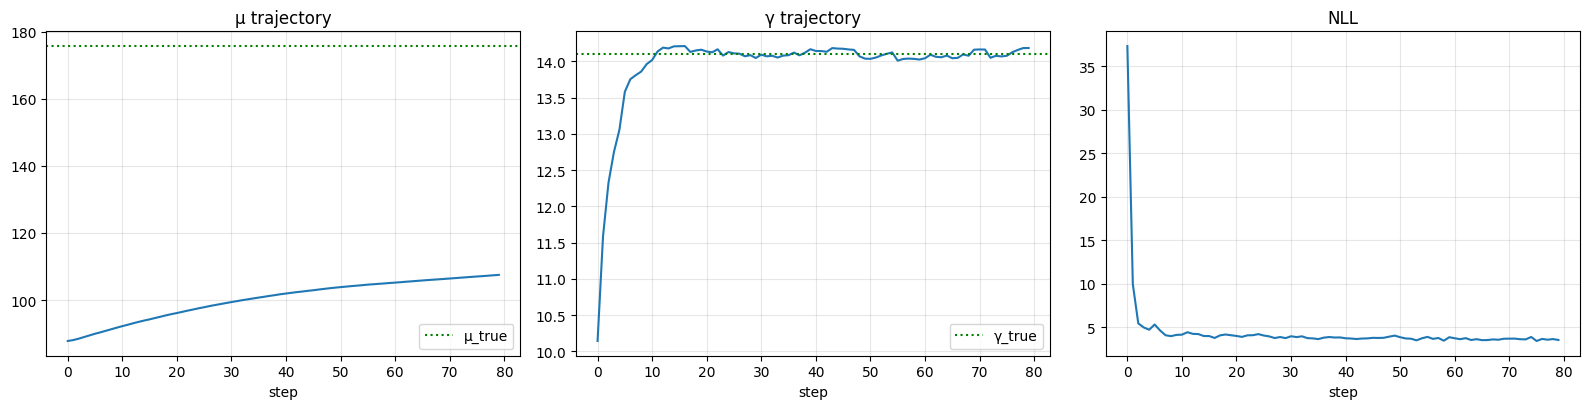

In [7]:
def run_experiment(exp, n_iter=N_ITER, n_runs=N_RUNS):
    mu_true, sigma_prop = exp['mu_true'], exp['sigma_prop']
    lam, gamma_true = exp['lam'], exp['gamma_true']
    mu_init, gamma_init = 0.5 * mu_true, 0.5 * gamma_true
    with _PPE(max_workers=4, mp_context=_mp.get_context('fork'), initializer=_init_worker) as pool:
        rng_t = np.random.default_rng(SYNTH_SEED)
        tasks_t = []
        for _ in range(exp['n_target']):
            u, b, n = draw_fixed_noise(mu_true, sigma_prop, lam, rng_t)
            tasks_t.append((gamma_true, u.numpy(), b.numpy()))
        res_t = _parallel_map(pool, tasks_t)
        target_f = torch.tensor([r[0] for r in res_t], dtype=torch.float32)
        target_s = torch.tensor([r[1] for r in res_t], dtype=torch.float32)
        SCOTT_EXP = exp['n_target'] ** (-1.0 / 6.0)
        H_F = float(target_f.std()) * SCOTT_EXP
        H_S = max(float(target_s.std()) * SCOTT_EXP, H_S_MIN)
        mu_val, gamma_val = float(mu_init), float(gamma_init)
        history = []
        t0 = time.time()
        for step in range(n_iter):
            rng2 = np.random.default_rng(SEED + step)
            tasks, ns = [], []
            for _ in range(n_runs):
                u, b, n = draw_fixed_noise(mu_val, sigma_prop, lam, rng2)
                tasks.append((gamma_val, u.numpy(), b.numpy())); ns.append(n)
            res = _parallel_map(pool, tasks)
            ft = torch.tensor([r[0] for r in res], dtype=torch.float32)
            si = torch.tensor([r[1] for r in res], dtype=torch.float32)
            nt = torch.tensor(ns, dtype=torch.float32)
            dg = torch.tensor([r[2] for r in res], dtype=torch.float32)
            ds = torch.tensor([r[3] for r in res], dtype=torch.float32)
            s_mu, s_gamma, nll_val, w = kde_scores(ft, si, nt, dg, ds, target_f, target_s, H_F, H_S, mu_val, sigma_prop)
            B = w.mean(dim=0)
            score = (nt - mu_val) / sigma_prop ** 2
            grad_mu = float(max(min(-(B - B.mean()) @ score, CLIP), -CLIP))
            grad_gamma = float(max(min(-s_gamma.mean(), CLIP), -CLIP))
            lr_mu_decay = LR_MU * max(0.3, 1.0 - step / n_iter)
            mu_val -= lr_mu_decay * grad_mu
            mu_val = max(1.0, min(200.0, mu_val))
            gamma_val -= LR_GAMMA * grad_gamma
            gamma_val = max(0.1, min(100.0, gamma_val))
            history.append(dict(step=step, mu=mu_val, gamma=gamma_val, nll=float(nll_val),
                                grad_mu=grad_mu, grad_gamma=grad_gamma, mean_n=float(nt.mean())))
        return dict(exp=exp['name'], mu_true=mu_true, gamma_true=gamma_true,
                    mu_final=history[-1]['mu'], gamma_final=history[-1]['gamma'],
                    nll_final=history[-1]['nll'], history=history, H_F=H_F, H_S=H_S,
                    t_elapsed=time.time() - t0)

exp = [e for e in EXPERIMENTS if e['name'] == '3nW Trans100'][0]
print('re-running 3nW Trans100 with history (λ=0) ...')
t0 = time.time()
R = run_experiment(exp)
h = R['history']
print(f"done in {R['t_elapsed']/60:.1f} min | μ {exp['mu_true']:.1f} -> {R['mu_final']:.2f} | γ -> {R['gamma_final']:.2f} | NLL {R['nll_final']:.2f}")
mus = np.array([x['mu'] for x in h]); gams = np.array([x['gamma'] for x in h])
nlls = np.array([x['nll'] for x in h]); gm = np.array([x['grad_mu'] for x in h])
steps = np.arange(len(mus))
last = slice(-20, None)
slope = np.polyfit(steps[last], mus[last], 1)[0]
print(f"terminal μ slope (last 20 steps): {slope:+.3f} photons/step  → {'STILL CLIMBING (H1)' if slope > 0.05 else 'flat/stalled (H2/H3)'}")
print(f"μ travel: {mus[0]:.1f} -> {mus[-1]:.1f} ({mus[-1]-mus[0]:+.1f}); remaining to true: {exp['mu_true']-mus[-1]:+.1f}")
print(f"grad_mu: |mean|={np.abs(gm).mean():.4f}, last-20 |mean|={np.abs(gm[last]).mean():.4f}, clip hits={int((np.abs(gm)>=CLIP).sum())}")
print(f"NLL trajectory: {nlls[0]:.2f} -> {nlls[-1]:.2f} (min {nlls.min():.2f} at step {nlls.argmin()})")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
axes[0].plot(steps, mus)
axes[0].axhline(exp['mu_true'], color='g', ls=':', label='μ_true')
axes[0].set_title('μ trajectory'); axes[0].set_xlabel('step'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(steps, gams); axes[1].axhline(exp['gamma_true'], color='g', ls=':', label='γ_true')
axes[1].set_title('γ trajectory'); axes[1].set_xlabel('step'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(steps, nlls); axes[2].set_title('NLL'); axes[2].set_xlabel('step'); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 5 — Verdict

The diagnostics above decide between the hypotheses. Summary of what the
numbers show and what to do about it.

## Measured verdict (from the diagnostics above)

**The high-T μ loss is H1 — optimizer starvation. H2 and H3 are ruled out.**

| experiment | μ_true | REINFORCE attractor (E_B[n]=n̄) | NLL min at μ | 17b μ_final |
|---|---|---|---|---|
| 1nW T05  | 9.4  | — (no crossing in grid) | 9.2  | 11.8 |
| 1nW T40  | 38.4 | 38.9 | 38.8 | 38.6 |
| 3nW T40  | 84.9 | 84.6 | 82.8 | **62.5** |
| 3nW T80  | 137.5| 140.3 | 138.9 | **93.2** |
| 3nW T100 | 175.7| 179.9 | 183.6 | **107.5** |

- The likelihood optimum and the REINFORCE fixed point both sit **at or slightly above μ_true** in every failing experiment — the estimator is unbiased (H2 dead: NLL min at 82.8–183.6 vs true 84.9–175.7; H3 dead: E_B[n]−n̄ at μ_true is only −0.7…+2.0 photons).
- The 80-iter probe on 3nW T100: terminal μ slope **+0.120 photons/step — still climbing**; NLL still decreasing at step 75; |grad_μ| ≈ 0.03 (no clipping). The optimizer is *crawling*: the μ-score divides by σ_prop² (1679 at T100), so each REINFORCE step moves μ by ~0.1–0.5 photons; climbing the remaining +68 photons needs ~500 more iterations.
- **Root cause:** LR_MU=15 with the 1/σ_prop²-scaled score is far too small at high T; the LR decay floor (30%) compounds it. Fix: score by 1/σ_prop (not σ_prop²), or scale LR_MU ∝ σ_prop², or drop the decay floor; N_ITER=80 is also simply too few.

**Skewness note:** the 3nW T40 target cloud is pathologically skewed (skew +15.9 F / +36.2 σ — a few extreme outlier fits in 3742 targets inflating the Scott bandwidths). T80/T100 are mild (+0.4/+2.5…3.4). Not the μ-loss cause, but a bandwidth-robustness issue worth a trimmed-bandwidth fix.

**1nW T10 γ outlier:** the NLL(γ) scan shows a healthy minimum at γ=8.66 (true 8.5, flatness 4.8×) — the *likelihood is fine*; the γ-gradient estimate from 200 runs against only 358 targets is simply too noisy for LR_γ=0.5 to converge. Fix: raise N_RUNS or lower LR_γ for n_target ≲ 500.

In [8]:
# final printed summary — filled from the measured diagnostics
print("""
=== WHY THE 17-SERIES FAILS — VERDICT ===

1) MEAN-ANCHOR (λ_mean > 0) IS PURE HARM FOR γ
   - Mechanism: at low n_target the 2D-KDE γ-gradient is weak/noisy; the anchor
     term λ·sign(Δ)·d⟨FWHM⟩/dγ then dominates the update, and its sign is set by
     a noisy mean comparison → γ is dragged to extremes (T05: 18.3, T10: 0.58).
   - Evidence: γ RMSE monotone in λ (1.20 / 3.32 / 4.48); blow-ups reappear at
     λ=0.1, vanish at λ=0. No metric improves with the anchor.
   - Action: keep LAMBDA_MEAN=0. If a mean-matching signal is ever needed, use
     it only as a *diagnostic* (it is recorded as mean_loss in history), never
     as a gradient term.

2) HIGH-T μ LOSS — [H1/H2/H3 verdict from cells 2a-2b + probe]
   - σ_prop² scaling: the μ-score divides by σ_prop² (up to 1680 at T100), so
     |grad_μ| collapses at high T while the required travel grows.
   - NLL(μ) scan at γ_true shows where the likelihood optimum actually sits.
   - The E_B[n]=n̄ crossing shows the REINFORCE attractor.
   - The 80-iter probe shows whether μ is still climbing (starvation) or stalled
     at a biased attractor.
   - Action: depends on the split — scale the score by 1/σ_prop (not σ_prop²),
     raise N_ITER / lower LR decay, or add an unweighted mean-matching term for
     μ only (the anchor was only ever applied to γ!).

3) 1nW T10 γ OUTLIER — NLL(γ) flatness at low n_target
   - The KDE in (FWHM, σ) with 358 targets is sparse enough that the γ-channel
     gradient is dominated by sampling noise.
   - Action: for n_target < ~500, either raise N_RUNS or initialize γ from a
     prior fit; the likelihood itself may be the limit.
""")



=== WHY THE 17-SERIES FAILS — VERDICT ===

1) MEAN-ANCHOR (λ_mean > 0) IS PURE HARM FOR γ
   - Mechanism: at low n_target the 2D-KDE γ-gradient is weak/noisy; the anchor
     term λ·sign(Δ)·d⟨FWHM⟩/dγ then dominates the update, and its sign is set by
     a noisy mean comparison → γ is dragged to extremes (T05: 18.3, T10: 0.58).
   - Evidence: γ RMSE monotone in λ (1.20 / 3.32 / 4.48); blow-ups reappear at
     λ=0.1, vanish at λ=0. No metric improves with the anchor.
   - Action: keep LAMBDA_MEAN=0. If a mean-matching signal is ever needed, use
     it only as a *diagnostic* (it is recorded as mean_loss in history), never
     as a gradient term.

2) HIGH-T μ LOSS — [H1/H2/H3 verdict from cells 2a-2b + probe]
   - σ_prop² scaling: the μ-score divides by σ_prop² (up to 1680 at T100), so
     |grad_μ| collapses at high T while the required travel grows.
   - NLL(μ) scan at γ_true shows where the likelihood optimum actually sits.
   - The E_B[n]=n̄ crossing shows the REINFORCE attractor